In [1]:
from google.colab import userdata     # Imports secret tokens for logins
from huggingface_hub import login     # Huggingface for fast implementation of transformers
import os
import sys
from pathlib import Path
file_path = ('/content/drive/My Drive/Thesis/belief-repr-1/')
sys.path.append(file_path)
if not os.path.exists('/content/drive/My Drive'):
    from google.colab import drive
    drive.mount('/content/drive')
secrets = {
    'hugging': userdata.get('hugging_token'),
    'wandb': userdata.get('wandb_api'),
    'nnsight': userdata.get('nnsight'),
    'openai': userdata.get('openai_api')
}

HF_TOKEN = secrets['hugging']
login(token=HF_TOKEN)

try:
    import transformer_lens as tlens
    import transformers as trans
    import openai
    import shap
except:
    #  git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python
    # %pip install wandb -qU
    # %pip install -U bitsandbytes
    # %pip install -U accelerate
    %pip install -U transformers transformer_lens datasets einops jaxtyping
    %pip install openai
    %pip install shap
    import openai
    import transformer_lens as tlens
    import transformers as trans
    import shap

"""
try:
    import sae_lens as slens
    from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
    )
    from sae_lens.toolkit.pretrained_saes_directory import get_pretrained_saes_directory
    from sae_vis import SaeVisConfig, SaeVisData, SaeVisLayoutConfig
except:
    # %pip install sae-lens
    #  git+https://github.com/callummcdougall/sae_vis.git@callum/v3
    %pip install openai>=1.56.2 nnsight
    %pip install --upgrade pydantic
    %pip install nnsight
"""

''' Navigate drive '''

import json
import pickle

''' For importing datasets '''

from datasets import load_dataset, Dataset

In [2]:
# import nnsight

# import circuitsvis as cv

''' Tensor manipulation '''

import einops
from einops import einsum
import numpy as np
import torch as t                     # https://pytorch.org/docs/stable/torch.html
import torch.nn as nn                 # https://pytorch.org/docs/stable/nn.html
import torch.nn.functional as F       # https://pytorch.org/docs/stable/nn.functional.html

''' Utils '''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from rich import print as rprint
from rich.table import Column, Table
from functools import partial         # We need this for fwd_hooks
import copy
from torch.amp import autocast
import gc
import seaborn as sns

''' Should we need strong typing '''

from jaxtyping import Float, Int
from torch import Tensor
from typing import Callable, List, Tuple

''' For visualization of progress (in notebook) and training behavior (in wandb) '''

from tqdm import tqdm
import wandb                          # REMEMBER to log training loops if you want to analyze that behavior | how to: wandb.init() before training, wandb.log() at each epoch, wandb.finish() to clean cache
wandb.login(key=secrets['wandb'])
device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

''' My things '''

from probes import SupervisedProbe, UnsupervisedProbe, probe_sweep
from visualization import *
from hooks import *
from utils import *
from data_sets import *
from intervention import *
from shots import *
from subjprobs import *

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alessandro-corona-m (alessandro-corona) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
best_layer = {'mmp': {
                'llama': 12,
                'llama_instruct': 14,
                'gemma': 25,
                'gemma_instruct': 30,
                'gpt-j': 22
                      },
              'lr': {
                'llama': 15,
                'llama_instruct': 13,
                'gemma': 27,
                'gemma_instruct': 28,
                'gpt-j': 13
                      }
              }

In [4]:
# linear_layer best lr for residual stream on llama == ~1e-2/1e-3
# mlp best lr for residual stream on llama == ~1e-4
# mmp returns immediate results
# no batching is the fastest and works very well for cities.csv
# diminishing return after the 100th epoch for good activations

class ProbeConfig:
    def __init__(self):
        """ General """
        self.device = device
        self.batch_size_extractor = 128
        self.seed = 42
        """ Probe setup """
        self.probe_type = "mmp" # Options: linear_layer | linear | mlp | mmp
        self.supervision = "S"
        self.direction_type = 'mmp'  # Options: linear | logistic | mmp
        self.verbose = False
        self.with_std = True
        self.var_normalize = True
        self.control = False
        """ Specs """
        self.batch_size = -1
        self.nepochs = 50
        self.ntries = 1
        self.lr = 1e-3
        self.weight_decay = 0.0
        self.dropout = 0.0
        self.C = 1e6
        self.max_iter = 500
        self.test_size = 0.1
        self.log_accuracy_on_recursive = True
        self.patience = 10

probe_config = ProbeConfig()

MODEL = 'llama'

''' Dictionary for all of the models '''

mymodels = {
    'gemma': lambda: tlens.HookedTransformer.from_pretrained("gemma-2-9b", device=t.device('cpu')).half(),
    'gemma_instruct': lambda: tlens.HookedTransformer.from_pretrained("gemma-2-9b-it", device=t.device('cpu')).half(),
    'llama': lambda: tlens.HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B", device=t.device('cpu')).half(),
    'llama_instruct': lambda: tlens.HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct", device=t.device('cpu')).half(),
    'gpt-j': lambda: tlens.HookedTransformer.from_pretrained("EleutherAI/gpt-j-6B", device=t.device('cpu')).half(),
}

model = mymodels[MODEL]()
model.to(device)

# TO DO: add SAE Hooked models

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Moving model to device:  cuda


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

# Datasets

In [5]:
if 'file_path' not in locals():
  import os
  import pickle
  import sys
  import pandas as pd
  file_path = ('/content/drive/My Drive/Thesis/belief-repr-1/')
  sys.path.append(file_path)
  if not os.path.exists('/content/drive/My Drive'):
      from google.colab import drive
      drive.mount('/content/drive')

CUTOFF = 1500

# Logical - easy
with open(f'{file_path}curated_dataset_full.pkl', 'rb') as file:
    curated_dataset = pickle.load(file)
with open(f'{file_path}neg_dataset.pkl', 'rb') as file:
    negated = pickle.load(file)
with open(f'{file_path}disj_dataset.pkl', 'rb') as file:
    disjunction = pickle.load(file)
with open(f'{file_path}conj_dataset.pkl', 'rb') as file:
    conjunction = pickle.load(file)
# Logical - inference
with open(f'{file_path}larger_than_inference.pkl', 'rb') as file:
    lt_inference = pickle.load(file)
with open(f'{file_path}smaller_than_inference.pkl', 'rb') as file:
    st_inference = pickle.load(file)
with open(f'{file_path}cities_inference.pkl', 'rb') as file:
    cities_inference = pickle.load(file)
with open(f'{file_path}companies_inference.pkl', 'rb') as file:
    companies_inference = pickle.load(file)
with open(f'{file_path}commonclaim_inference.pkl', 'rb') as file:
    cc_inference = pickle.load(file)
with open(f'{file_path}counterfact_inference.pkl', 'rb') as file:
    cf_inference = pickle.load(file)
# Other datasets
with open(f'{file_path}mymulan.pkl', 'rb') as file:
    mulan = pickle.load(file)
with open(f'{file_path}tqa_curated.pkl', 'rb') as file:
    tqa = pickle.load(file)
with open(f'{file_path}likely.pkl', 'rb') as file:
    likely = pickle.load(file)
with open(f'{file_path}entailment_new.pkl', 'rb') as file:
    entailment_new = pickle.load(file)

# Clean 'negated'

new_column_for_neg = curated_dataset[curated_dataset['filename'].isin(['common_claim_true_false.csv', 'companies_true_false.csv', 'counterfact_true_false.csv'])]
new_column_for_neg['filename'].unique()
negated = negated.rename(columns={'statement':'new_statement'})
negated['statement'] = new_column_for_neg['statement']
negated = negated[['statement', 'new_statement', 'label', 'filename']]

# Mulan division

mulan_mutable = mulan[mulan['type'] == 'mutable']
mulan_immutable = mulan[mulan['type'] == 'immutable']
mulan_mutable = stratified_sample(mulan_mutable, 'relation', CUTOFF)
mulan_immutable = stratified_sample(mulan_immutable, 'relation', CUTOFF)

# Cross-datasets cutoff

cut_tqa = stratified_sample(tqa, 'Category', CUTOFF)
cut_tqa = cut_tqa.rename(columns={'Statement':'statement'})
cut_tqa = cut_tqa.rename(columns={'Label':'label'})
cut_curated = stratified_sample(curated_dataset, 'filename', CUTOFF)
cut_likely = stratified_sample(likely, 'filename', CUTOFF)

# Fix entailments

cities_inference['new_statement'] = cities_inference['specific_statement'].fillna(cities_inference['generic_statement'])
companies_inference['new_statement'] = companies_inference['specific_statement'].fillna(companies_inference['generic_statement'])
# entailment = pd.concat([cities_inference, companies_inference, cc_inference, cf_inference])
# entailment.loc[entailment['label'] == 0, ['statement', 'new_statement']] = entailment.loc[entailment['label'] == 0, ['new_statement', 'statement']].values

# Final cuts

negated['label'] = 1 - negated['label']
negated['neg_label'] = 1 - negated['label']
remainder = curated_dataset[~curated_dataset['filename'].isin(['common_claim_true_false.csv', 'companies_true_false.csv', 'counterfact_true_false.csv',
                                                              #  'cities.csv', 'cities_cities_conj.csv', 'cities_cities_disj.csv', 'neg_cities.csv'
                                                               ])]
# curated_dataset_neg = pd.concat([negated, remainder])
# curated_disj = pd.concat([disjunction, remainder])
# curated_conj = pd.concat([conjunction, remainder])

In [ ]:
def stratified_fixed_sample(df, stratify_col, n, random_state=42):
    # Get the proportions of each class
    proportions = df[stratify_col].value_counts(normalize=True)

    # Calculate number of samples per class
    per_class_n = (proportions * n).round().astype(int)

    # Ensure total is exactly n (adjust due to rounding)
    diff = n - per_class_n.sum()
    if diff != 0:
        # Sort classes by largest fractional part and adjust
        fractional = (proportions * n) - (proportions * n).round()
        adjust_classes = fractional.abs().sort_values(ascending=False).index
        for i in range(abs(diff)):
            per_class_n[adjust_classes[i % len(adjust_classes)]] += int(diff / abs(diff))

    # Sample from each class
    sampled = []
    for label, count in per_class_n.items():
        sampled.append(df[df[stratify_col] == label].sample(n=count, random_state=random_state))

    return pd.concat(sampled)


In [ ]:
rest_curated = stratified_fixed_sample(curated_dataset, 'filename', CUTOFF)
curated_train = curated_dataset[~curated_dataset.index.isin(rest_curated.index)]

In [6]:
curated_train, curated_test = train_test_split(
    curated_dataset,
    test_size=0.2,
    random_state=42,
    stratify=curated_dataset['filename']
)
# curated_train = curated_train[curated_train['statement'].apply(lambda x: isinstance(x, str))]
# curated_train = cut_curated[cut_curated['statement'].apply(lambda x: isinstance(x, str))]
curated_trimmed = curated_train.iloc[:-(len(curated_train) % probe_config.batch_size_extractor), :]
# For entailment
# curated_test = rest_curated.drop(columns=['specific_statement', 'generic_statement'])
# curated_test = curated_test.dropna()

X_clean_train = list(curated_trimmed['statement'])
y_clean_train = list(curated_trimmed['label'])

## Training Loop Ahh

# Probe training

In [7]:
# == Resid

model.reset_hooks()
resid_extractor = ActivationExtractor(model=model, data=X_clean_train, labels=y_clean_train, device=device, half=True,
                                      batch_size=probe_config.batch_size_extractor)
resid_extractor.set_hooks(
                          [best_layer[probe_config.probe_type][MODEL]],
                          [tlens.utils.get_act_name('resid_post')], attn=False) # for instance
resid_activations, resid_labels = resid_extractor.process() # Get

model.to(t.device('cpu'))
gc.collect()
t.cuda.empty_cache()

Moving model to device:  cuda


Processing: 100%|██████████| 114/114 [03:14<00:00,  1.71s/it]


Moving model to device:  cpu


### We start with a single training loop for each module to find the best candidates (and we keep the best candidates for MMPs)

In [21]:
import warnings
warnings.filterwarnings("ignore", message=".*To copy construct from a tensor.*")

probe_config.verbose=False
probe_config.control=False
probe_config.lr=0.0009
probe_config.nepochs=1000
probe_config.batch_size=512
probe_config.dropout=0.2

dataset = einops.rearrange(next(iter(resid_activations.values())), 'n b d -> (n b) d')
gold = einops.rearrange(resid_labels, 'n b -> (n b)')
X_train, X_test, y_train, y_test = train_test_split(dataset, gold, test_size=probe_config.test_size, random_state=probe_config.seed)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

master_probe, directions = form_master_probe(probe_config, X_train, y_train, X_test, y_test, n=1)
master_probe.to(device)

Epochs:  40%|███▉      | 397/1000 [01:03<01:36,  6.27it/s]

Early stopping triggered at epoch 398
Run 1/1 accuracy: 0.8719


Sequential(
  (0): FixedLinear()
  (1): Sigmoid()
)

### Wald Test

In [22]:
def extract_beta_from_linear(layer):
    """Return np.array([intercept, w1, ..., wd])"""
    W = layer.weight.detach().cpu().numpy().reshape(-1)
    # b = float(layer.bias.detach().cpu().numpy().reshape(()))
    return W

def add_intercept(X):
    """Add intercept column (ones) to X."""
    return np.c_[np.ones((X.shape[0], 1)), X]


from scipy.special import expit
from numpy.linalg import inv
from scipy.stats import norm, chi2

def wald_test_binary_logit(layer, X, y_train):
    beta = extract_beta_from_linear(layer)        # (d+1,)
    # X = add_intercept(np.asarray(X_train))        # (n, d+1)
    y = np.asarray(y_train).reshape(-1)

    # fitted probs
    p = expit(X @ beta)                           # (n,)
    W = p * (1 - p)                               # (n,)

    # observed information
    XTWX = X.T @ (W[:, None] * X)                 # (d+1, d+1)

    # covariance matrix of betas
    cov_beta = inv(XTWX)
    se = np.sqrt(np.diag(cov_beta))

    # Wald z stats
    z = beta / se
    p_two_sided = 2 * (1 - norm.cdf(np.abs(z)))

    # results table
    names = ["intercept"] + [f"x{j}" for j in range(1, X.shape[1])]
    table = pd.DataFrame({
        "term": names,
        "beta_hat": beta,
        "SE": se,
        "wald_z": z,
        "p_value": p_two_sided
    })

    # joint test (all slopes together, excluding intercept)
    idx = np.arange(1, X.shape[1])
    R = np.eye(X.shape[1])[idx]                   # restriction matrix
    beta_R = R @ beta
    cov_R = R @ cov_beta @ R.T
    chi2_stat = float(beta_R.T @ np.linalg.inv(cov_R) @ beta_R)
    p_joint = 1 - chi2.cdf(chi2_stat, df=len(idx))

    return table, {"chi2": chi2_stat, "df": len(idx), "p_value": p_joint}

linear_layer = master_probe[0]

wald_table, joint_test = wald_test_binary_logit(linear_layer, X_train, y_train.cpu())

print(wald_table)   # per-coefficient test
print("Joint Wald test:", joint_test)

           term  beta_hat        SE    wald_z   p_value
0     intercept -0.103904  3.318063 -0.031315  0.975019
1            x1 -0.082847  3.595068 -0.023045  0.981615
2            x2  0.085979  4.734250  0.018161  0.985510
3            x3 -0.022645  5.265686 -0.004301  0.996569
4            x4  0.096095  4.232595  0.022704  0.981887
...         ...       ...       ...       ...       ...
4091      x4091  0.004877  4.748146  0.001027  0.999180
4092      x4092  0.032530  6.542570  0.004972  0.996033
4093      x4093  0.028558  4.300453  0.006641  0.994702
4094      x4094 -0.226325  2.926089 -0.077347  0.938347
4095      x4095  0.027320  6.164306  0.004432  0.996464

[4096 rows x 5 columns]
Joint Wald test: {'chi2': 3706.0152241339733, 'df': 4095, 'p_value': 0.9999953961329945}


In [23]:
def top_abs_betas(wald_table, k=10):
    df = wald_table.copy()
    df["abs_beta"] = df["beta_hat"].abs()
    top = df.sort_values("abs_beta", ascending=False).head(k)
    return top

top10 = top_abs_betas(wald_table, k=10)
print(top10)


       term  beta_hat        SE    wald_z   p_value  abs_beta
973    x973 -1.064354  1.840308 -0.578357  0.563023  1.064354
192    x192 -0.849924  1.460137 -0.582085  0.560509  0.849924
252    x252 -0.828048  1.459081 -0.567513  0.570365  0.828048
149    x149 -0.773755  1.689851 -0.457884  0.647036  0.773755
2531  x2531  0.763497  1.639773  0.465611  0.641494  0.763497
3720  x3720  0.649352  2.560676  0.253586  0.799815  0.649352
2931  x2931  0.644825  2.088311  0.308778  0.757490  0.644825
4040  x4040 -0.632689  1.736861 -0.364272  0.715655  0.632689
2516  x2516  0.614383  1.591334  0.386081  0.699437  0.614383
2492  x2492 -0.607377  1.928575 -0.314936  0.752810  0.607377




In [16]:
def plot_wald_heatmap(wald_table: pd.DataFrame, top_k=None):
    """
    wald_table columns expected: ['term','beta_hat','SE','wald_z','p_value'].
    If top_k is set, only the top_k features by |wald_z| are shown.
    """
    df = wald_table.copy()

    # sort by |z|
    df["_abs_z"] = df["wald_z"].abs()
    df = df.sort_values("_abs_z", ascending=False)
    if top_k is not None:
        df = df.iloc[:top_k]

    # matrix: rows = metrics, cols = terms
    terms = df["term"].tolist()
    z = df["wald_z"].to_numpy()
    neglogp = -np.log10(np.clip(df["p_value"].to_numpy(), 1e-300, 1.0))

    M = np.vstack([z, neglogp])  # shape (2, d)

    fig, ax = plt.subplots(figsize=(max(6, len(terms) * 0.35), 3.8))
    im = ax.imshow(M, aspect="auto")

    # axis labels
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["wald_z", "-log10(p)"])
    ax.set_xticks(np.arange(len(terms)))
    ax.set_xticklabels(terms, rotation=90, ha="center")

    # grid-like separators for readability
    ax.set_xticks(np.arange(-.5, len(terms), 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # colorbar (default cmap)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("value")

    plt.title("Wald statistics heatmap")
    plt.tight_layout()
    plt.show()

plot_wald_heatmap(wald_table)

In [ ]:
# Mass-mean Probe

with t.autocast('cuda'):
  X_train = X_train.astype(np.float32)
  X_test = X_test.astype(np.float32)
  probe_config.var_normalize = False
  mm_probe = SupervisedProbe(x_train=X_train, labels_train=y_train,
                          x_test=X_test, labels_test=y_test,
                          probe_cfg=probe_config)
  mm_probe.repeated_train()
  mm = mm_probe.get_direction()
  mm_acc = mm_probe.get_acc()

0.7163120567375887


In [ ]:
# cleanup resid activations and labels from device

del resid_activations
del resid_labels
gc.collect()
t.cuda.empty_cache()

# Tests - Interp

## Conj/Disj/Neg/CrossDataset

In [ ]:
# Extract representations for test set

X_hop = None

df_a = curated_test.iloc[:-(len(curated_test) % probe_config.batch_size_extractor)]
df_b = curated_test.iloc[:-(len(curated_test) % probe_config.batch_size_extractor)]

# X_base = list(df['statement'])
# X_hop = list(df['hop_statement'])
# X_paraph = list(df['new_statement'])
labels = list(df['label'])  # Only necessary for neg/conj/disj

# X_base = cut_curated['statement']
X_base = mulan_immutable['statement']
# X_paraph = cut_tqa['statement']
# X_paraph = cut_likely['statement']
X_paraph = mulan_mutable['statement']

In [ ]:
''' Set up X_base and X_paraph '''

model.reset_hooks()
base_extractor = ActivationExtractor(model=model, data=X_base, labels=labels, device=device, half=True,
                                      batch_size=probe_config.batch_size_extractor)
base_extractor.set_hooks(
                          [best_layer[probe_config.probe_type][MODEL]],
                          [tlens.utils.get_act_name('resid_post')], attn=False) # for instance
base_activations, base_labels = base_extractor.process() # Get
# model.reset_hooks()
paraph_extractor = ActivationExtractor(model=model, data=X_paraph, labels=labels, device=device, half=True,
                                      batch_size=probe_config.batch_size_extractor)
paraph_extractor.set_hooks(
                          [best_layer[probe_config.probe_type][MODEL]],
                          [tlens.utils.get_act_name('resid_post')], attn=False) # for instance
paraph_activations, paraph_labels = paraph_extractor.process() # Get

base_activations_values = base_activations[next(iter(base_activations))]
base_activations_values = einops.rearrange(base_activations_values, 'n b d -> (n b) d')
base_activations_values = scaler.transform(base_activations_values)
paraph_activations_values = paraph_activations[next(iter(paraph_activations))]
paraph_activations_values = einops.rearrange(paraph_activations_values, 'n b d -> (n b) d')
paraph_activations_values = scaler.transform(paraph_activations_values)

if X_hop is not None:   # Get data for entailment
  model.reset_hooks()
  hop_extractor = ActivationExtractor(model=model, data=X_hop, labels=labels, device=device, half=True,
                                        batch_size=probe_config.batch_size_extractor)
  hop_extractor.set_hooks(
                            [best_layer[probe_config.probe_type][MODEL]],
                            [tlens.utils.get_act_name('resid_post')], attn=False) # for instance
  hop_activations, hop_labels = hop_extractor.process() # Get

  hop_activations_values = hop_activations[next(iter(hop_activations))]
  hop_activations_values = einops.rearrange(hop_activations_values, 'n b d -> (n b) d')
  hop_activations_values = scaler.transform(hop_activations_values)

model.to(t.device('cpu'))
gc.collect()
t.cuda.empty_cache()

Moving model to device:  cuda


Processing: 100%|██████████| 11/11 [00:05<00:00,  2.15it/s]


Moving model to device:  cuda


Processing: 100%|██████████| 11/11 [00:08<00:00,  1.32it/s]


Moving model to device:  cpu


### Master Probe

In [ ]:
master_base_probabilities = master_probe(t.tensor(base_activations_values, device=device, dtype=t.float32))
master_paraph_probabilities = master_probe(t.tensor(paraph_activations_values, device=device, dtype=t.float32))
df['master_label_base'] = master_base_probabilities.cpu().numpy() > 0.5
df['master_label_paraph'] = master_paraph_probabilities.cpu().numpy() > 0.5
df['master_proba_base'] = master_base_probabilities.cpu().numpy()
df['master_proba_paraph'] = master_paraph_probabilities.cpu().numpy()
if X_hop is not None:
  master_hop_probabilities = master_probe(t.tensor(hop_activations_values, device=device, dtype=t.float32))
  df['master_label_hop'] = master_hop_probabilities.cpu().numpy() > 0.5
  df['master_proba_hop'] = master_hop_probabilities.cpu().numpy()

/content/drive/My Drive/Thesis/belief-repr-1/subjprobs.py:55: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  return t.matmul(x, self.weight.T)
/tmp/ipython-input-3291667168.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['master_label_base'] = master_base_probabilities.cpu().numpy() > 0.5
/tmp/ipython-input-3291667168.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

### MMP

In [ ]:
with t.autocast('cuda'):

  mm_base_probabilities = mm_probe.probe(t.tensor(base_activations_values, device=device, dtype=t.float32))
  mm_paraph_probabilities = mm_probe.probe(t.tensor(paraph_activations_values, device=device, dtype=t.float32))
  df['mm_label_base'] = mm_base_probabilities.detach().cpu().numpy() > 0.5
  df['mm_label_paraph'] = mm_paraph_probabilities.detach().cpu().numpy() > 0.5
  df['mm_proba_base'] = mm_base_probabilities.detach().cpu().numpy()
  df['mm_proba_paraph'] = mm_paraph_probabilities.detach().cpu().numpy()
  if X_hop is not None:
    mm_hop_probabilities = mm_probe.probe(t.tensor(hop_activations_values, device=device, dtype=t.float32))
    df['mm_label_hop'] = master_hop_probabilities.detach().cpu().numpy() > 0.5
    df['mm_proba_hop'] = master_hop_probabilities.detach().cpu().numpy()

/tmp/ipython-input-354417761.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mm_label_base'] = mm_base_probabilities.detach().cpu().numpy() > 0.5
/tmp/ipython-input-354417761.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mm_label_paraph'] = mm_paraph_probabilities.detach().cpu().numpy() > 0.5
/tmp/ipython-input-354417761.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

# Tests - Non-interp

## Self-reporting

In [ ]:
model.reset_hooks()
model.to(device)
def embed_to_half_hook(tensor, hook):
    return tensor.half()

model.add_hook("hook_embed", embed_to_half_hook)

import gc

context = "I am a fact-checking AI. For each statement, I determine whether it is True or False and rate my confidence in that judgment on a scale from 0 to 1."
shots = [
    'Statement: Paris is the capital of France.\nAnswer: True\nConfidence: 0.95',
    'Statement: The largest bear in the world is currently in Italy.\nAnswer: False\nConfidence: 0.75',
    'Statement: Milan is the capital of Italy.\nAnswer: False\nConfidence: 0.85',
    'Statement: Pythagoras was originally from Turkey.\nAnswer: False\nConfidence: 0.70'
]

tqdm.pandas()


Moving model to device:  cuda


In [ ]:
def self_reporting_confidence(model: HookedTransformer,
                              prompt: str,
                              context: str = context,
                              shots: List[str] = shots,
                              device: str = "cuda") -> Float:
    """
    Computes the self-reporting probabilities for a batch of tokens using a pre-trained model.
    Cleans up CUDA memory after use to prevent OOM when called repeatedly.
    """

    try:
        context = context + '\n'
        shots = '\n'.join(shots)
        full_prompt = context + shots + '\n' + f'{prompt}\nAnswer:'

        with t.no_grad(), t.autocast(device):
            answer = generate(model=model, prompt=full_prompt, temperature=0, max_length=10)
        match = re.search(r'\d+\.\d+', answer)
        if match:
            truth_value = answer.split()[0]
            confidence = float(match.group())
        else:
            print(f"Warning: No confidence score found in the answer: {answer}")
            truth_value = "Unknown"
            confidence = float('nan')

        confidence = max(confidence, 1 - confidence)

        if re.fullmatch(r'(Ġ)?(False|false|FALSE)(\.)?', str(truth_value)):
            confidence = 1 - confidence

        return truth_value, confidence

    finally:
        # Force cleanup of unused memory
        gc.collect()
        torch.cuda.empty_cache()

In [ ]:
tqdm.pandas()

# df = curated_test.iloc[:-(len(curated_test) % probe_config.batch_size_extractor)]

def self_evaluate_row(prompt):
    truth, conf = self_reporting_confidence(model, prompt)
    return pd.Series({'truth': truth, 'confidence': conf})

# Apply it to the DataFrame
# df[['self_label_base', 'self_proba_base']] = cibo.progress_apply(self_evaluate_row)
df[['self_label_base', 'self_proba_base']] = df['statement'].progress_apply(self_evaluate_row)
df[['self_label_paraph', 'self_proba_paraph']] = df['new_statement'].progress_apply(self_evaluate_row)
if X_hop is not None:
  df[['self_label_hop', 'self_proba_hop']] = df['hop_statement'].progress_apply(self_evaluate_row)

backup_df = df
df = df.dropna()

''' Cross-dataset '''

# df[['self_label_base', 'self_proba_base']] = cut_curated['statement'].apply(self_evaluate_row)
# df[['self_label_base', 'self_proba_base']] = mulan_immutable['statement'].apply(self_evaluate_row)
# df[['self_label_paraph', 'self_proba_paraph']] = cut_tqa['statement'].apply(self_evaluate_row)
# df[['self_label_paraph', 'self_proba_paraph']] = cut_likely['statement'].apply(self_evaluate_row)
# df[['self_label_paraph', 'self_proba_paraph']] = mulan_mutable['statement'].apply(self_evaluate_row)

  1%|          | 8/1408 [00:09<28:11,  1.21s/it]

  1%|          | 10/1408 [00:12<28:05,  1.21s/it]

Confidence:
<eos>


  2%|▏         | 33/1408 [00:47<34:40,  1.51s/it]

Number of times the word "yes"


...

100%|█████████▉| 1404/1408 [35:21<00:06,  1.53s/it]

Confidence: 4


100%|█████████▉| 1407/1408 [35:26<00:01,  1.53s/it]

100%|██████████| 1408/1408 [35:29<00:00,  1.51s/it]
/tmp/ipython-input-3769122552.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b[['self_label_paraph', 'self_proba_paraph']] = df_b['statement'].progress_apply(self_evaluate_row)
/tmp/ipython-input-3769122552.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b[['self_label_paraph', 'self_proba_paraph']] = df_b['statement'].progress_apply(self_evaluate_row)


' Cross-dataset '

## Logit-based estimate

In [ ]:
def logit_confidence(model: HookedTransformer,
                    prompt: str,
                    context: str = context,
                    shots: List[str] = shots,
                    device: str = "cuda") -> Float:
    with t.amp.autocast('cuda'):
      #Ġ
      #▁
      true_token_ids = [model.tokenizer.convert_tokens_to_ids(token) for token in ['true', 'True', 'TRUE', 'Ġtrue', 'ĠTrue', 'ĠTRUE']]
      false_token_ids = [model.tokenizer.convert_tokens_to_ids(token) for token in ['false', 'False', 'FALSE', 'Ġfalse', 'ĠFalse', 'ĠFALSE']]
      full_prompt = context + '\n'.join(shots) + '\n' + f'{prompt}\nAnswer:'
      tokens = model.to_tokens(full_prompt)
      logits = model(tokens)
      log_probs = t.nn.functional.log_softmax(logits, dim=-1)
      selected_token_ids = true_token_ids + false_token_ids
      restricted_log_probs = log_probs[0, -1, selected_token_ids]
      restricted_probs = t.exp(restricted_log_probs)
      p_true = restricted_probs[:len(true_token_ids)].sum().item()
      p_false = restricted_probs[len(true_token_ids):].sum().item()
      normalized_p_true = p_true / (p_true + p_false)
      normalized_p_false = p_false / (p_true + p_false)
      truth_value = 'True' if normalized_p_true > normalized_p_false else 'False'
      if p_true + p_false < 0.05:
          # If the model is not confident, we set the truth value to 0.5
          print("Warning: model underconfident")
          normalized_p_true = 0.5
    return truth_value, normalized_p_true

NameError: name 'context' is not defined

In [ ]:
def logit_evaluate_row(prompt):
    with t.no_grad():
        truth, conf = logit_confidence(model, prompt, context='')
    return pd.Series({'truth': truth, 'confidence': conf})

# Apply it to the DataFrame
df[['logit_label_base', 'logit_proba_base']] = df['statement'].progress_apply(logit_evaluate_row)
df[['logit_label_paraph', 'logit_proba_paraph']] = df['new_statement'].progress_apply(logit_evaluate_row) # Fix with the correct column
if X_hop is not None:
  df[['logit_label_hop', 'logit_proba_hop']] = df['hop_statement'].progress_apply(logit_evaluate_row)

''' Cross-dataset '''

# df[['self_label_base', 'self_proba_base']] = cut_curated['statement'].apply(logit_evaluate_row)
# df[['self_label_base', 'self_proba_base']] = mulan_immutable['statement'].apply(logit_evaluate_row)
# df[['self_label_paraph', 'self_proba_paraph']] = cut_tqa['statement'].apply(logit_evaluate_row)
# df[['self_label_paraph', 'self_proba_paraph']] = cut_likely['statement'].apply(logit_evaluate_row)
# df[['self_label_paraph', 'self_proba_paraph']] = mulan_mutable['statement'].apply(logit_evaluate_row)

100%|██████████| 1126/1126 [01:17<00:00, 14.55it/s]
/tmp/ipython-input-743420315.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['logit_label_base', 'logit_proba_base']] = df['statement'].progress_apply(logit_evaluate_row)
/tmp/ipython-input-743420315.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['logit_label_base', 'logit_proba_base']] = df['statement'].progress_apply(logit_evaluate_row)
100%|██████████| 1126/1126 [01:18<00:00, 14.42it/s]
/tmp/ipython-input-743420315.py:8: SettingWithCopy

' Cross-dataset '

## We have full probas. Let us turn to evaluation

In [ ]:
random_base = t.rand(len(df))
random_hop = t.rand(len(df))
random_base = np.array(df['logit_proba_base'])
np.random.shuffle(random_base)
random_hop = np.array(df['logit_proba_paraph'])
np.random.shuffle(random_base)

In [ ]:
1/(1+t.mean(((t.tensor(random_base+random_hop)) - t.ones_like(t.tensor(random_base)))**2))

tensor(0.8897, dtype=torch.float64)

In [ ]:
random_base = np.array(df['logit_proba_base'])
np.random.shuffle(random_base)
random_paraph = np.array(df['logit_proba_paraph'])

In [ ]:
def plot_histogram(
    data,
    bins=30,
    title="Credence distribution",
    xlabel="Value",
    ylabel="Frequency",
    figsize=(10, 6),
    grid=True,
    color=None,
    edgecolor='black',
    alpha=0.7,
    density=False,
    show_mean=True,
    show_median=True,
):
    plt.figure(figsize=figsize)

    color = color or plt.cm.viridis(0.6)

    # Histogram
    counts, bins_edges, patches = plt.hist(
        data,
        bins=bins,
        color=color,
        edgecolor=edgecolor,
        alpha=alpha,
        density=density
    )

    # Optional lines
    if show_mean:
        mean_val = np.mean(data)
        plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    if show_median:
        median_val = np.median(data)
        plt.axvline(median_val, color='orange', linestyle='-', label=f'Median: {median_val:.2f}')

    # Labels and title
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if grid:
        plt.grid(visible=True, linestyle='--', alpha=0.5)

    plt.legend()
    plt.tight_layout()
    plt.show()


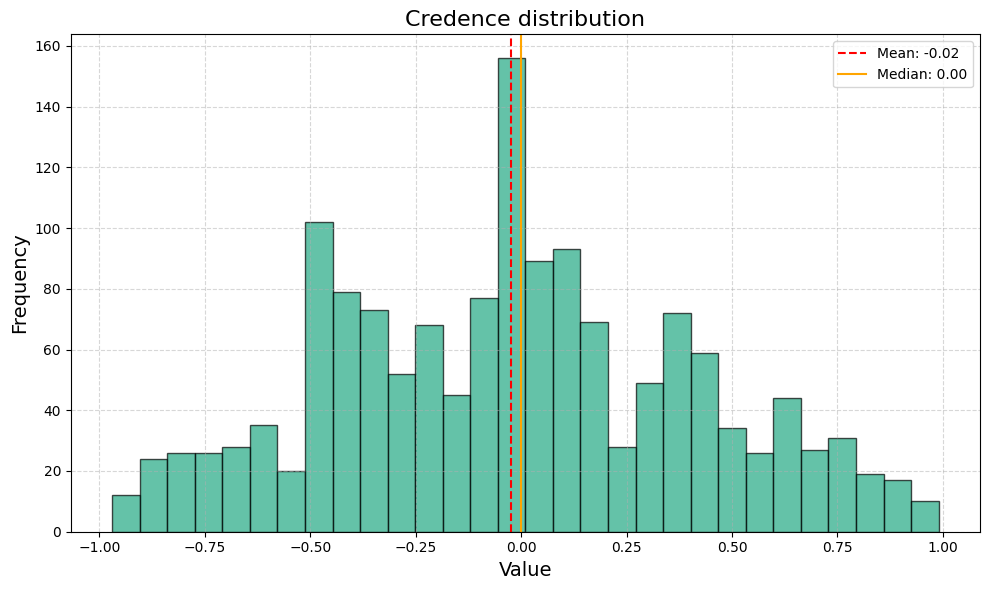

In [ ]:
plot_histogram(np.array(df['self_proba_paraph'].tolist() - np.array(df['self_proba_base'].tolist()) ))

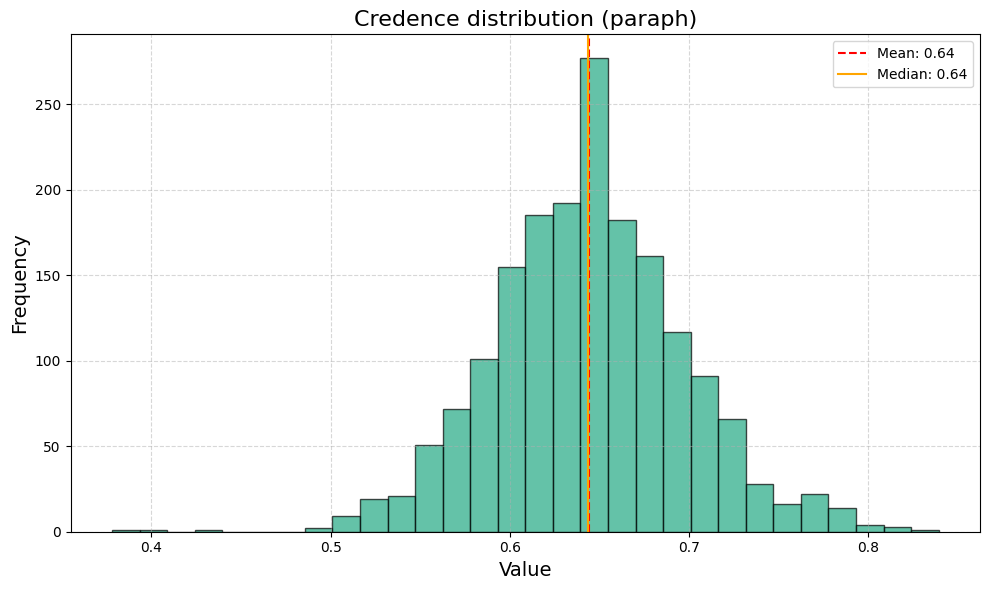

In [ ]:
plot_histogram(((df['logit_proba_base'])), title="Credence distribution (paraph)")

In [ ]:
df

,statement,new_statement,label,new_label,filename,master_label_base,master_label_paraph,master_proba_base,master_proba_paraph,mm_label_base,...,mm_proba_base,mm_proba_paraph,self_label_base,self_proba_base,self_label_paraph,self_proba_paraph,logit_label_base,logit_proba_base,logit_label_paraph,logit_proba_paraph
7579,SAP operates in the industry of it software & ...,It is both the case that SAP operates in the i...,1,0.0,conj_companies_true_false.csv,True,False,0.921153,0.001944,True,...,0.843262,4.977417e-02,True,0.91,False,0.30,True,0.820431,False,0.155205
2217,Actors and actresses collect resumes on other ...,It is both the case that Actors and actresses ...,0,0.0,conj_common_claim_true_false.csv,False,False,0.029697,0.010601,False,...,0.486328,8.422852e-01,True,0.75,False,0.30,True,0.547478,True,0.617022
6570,Albert Richardson is native to London.,It is both the case that Albert Richardson is ...,1,1.0,conj_counterfact_true_false.csv,True,False,0.784165,0.457345,True,...,0.994141,1.448975e-01,True,0.92,True,0.78,True,0.619275,True,0.641333
3435,Citigroup has headquarters in United States.,It is both the case that Citigroup has headqua...,1,0.0,conj_companies_true_false.csv,True,True,0.944772,0.884072,True,...,0.998047,2.751465e-01,True,0.99,True,0.87,True,0.887448,False,0.362479
268,Most of the tissue in human brains is fat.,It is both the case that Most of the tissue in...,0,0.0,conj_common_claim_true_false.csv,False,True,0.029086,0.740965,False,...,0.052338,1.000000e+00,False,0.25,True,0.90,True,0.793592,True,0.805342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,"In China, the world's population is around fiv...","It is both the case that In China, the world's...",1,0.0,conj_common_claim_true_false.csv,False,False,0.433385,0.112765,True,...,0.986328,9.624023e-01,False,0.27,False,0.35,False,0.422578,True,0.720213
627,One in four people will experience a mental he...,It is both the case that One in four people wi...,1,0.0,conj_common_claim_true_false.csv,True,True,0.957889,0.556455,True,...,0.990234,1.649170e-01,True,0.73,False,0.26,True,0.836027,True,0.670692
6731,"In Locarno, they understand Swedish.","It is both the case that In Locarno, they unde...",0,0.0,conj_counterfact_true_false.csv,False,True,0.024176,0.546555,False,...,0.220459,9.222412e-02,True,0.77,False,0.28,False,0.366304,True,0.710114
5347,Flies produce totally different toxic juice wh...,It is both the case that Flies produce totally...,0,0.0,conj_common_claim_true_false.csv,False,False,0.014169,0.018639,False,...,0.060974,1.192093e-07,False,0.21,True,0.70,True,0.547408,True,0.643229


In [ ]:
judge_negation = JudgeCoherence(logic='neg')
judge_disjunction = JudgeCoherence(logic='disj')
judge_conjunction = JudgeCoherence(logic='conj')
judge_ent = JudgeCoherence(logic='ent')
judge_ent_ = JudgeCoherence(logic='ent*')

backup_df = df

# example
# judge_negation.set_metric(judge_negation.rmse_metric)
# performance_negation_master = judge_negation.judge([t.tensor(list(df['master_proba_base'])), t.tensor(list(df['master_proba_paraph']))])
# performance_negation_mm = judge_negation.judge([t.tensor(list(df['mm_proba_base'])), t.tensor(list(df['mm_proba_paraph']))])
# performance_negation_self = judge_negation.judge([t.tensor(list(df['self_proba_base'])), t.tensor(list(df['self_proba_paraph']))])
# performance_negation_logit = judge_negation.judge([t.tensor(list(df['logit_proba_base'])), t.tensor(list(df['logit_proba_paraph']))])
# print(1/(1+performance_negation_master))
# print(1/(1+performance_negation_mm))
# print(1/(1+performance_negation_self))
# print(1/(1+performance_negation_logit))
# judge_disjunction.set_metric(judge_disjunction.less_than_perc)
# performance_disjunction_master = judge_disjunction.judge([t.tensor(list(df['master_proba_base'])), t.tensor(list(df['master_proba_paraph']))])
# performance_disjunction_mm = judge_disjunction.judge([t.tensor(list(df['mm_proba_base'])), t.tensor(list(df['mm_proba_paraph']))])
# performance_disjunction_self = judge_disjunction.judge([t.tensor(list(df['self_proba_base'])), t.tensor(list(df['self_proba_paraph']))])
# performance_disjunction_logit = judge_disjunction.judge([t.tensor(list(df['logit_proba_base'])), t.tensor(list(df['logit_proba_paraph']))])
# print(performance_disjunction_master)
# print(performance_disjunction_mm)
# print(performance_disjunction_self)
# print(performance_disjunction_logit)
judge_disjunction.set_metric(judge_disjunction.less_than_perc)
performance_disjunction_master = judge_disjunction.judge([t.tensor(list(df['master_proba_base'])), t.tensor(list(df['master_proba_paraph']))])
performance_disjunction_mm = judge_disjunction.judge([t.tensor(list(df['mm_proba_base'])), t.tensor(list(df['mm_proba_paraph']))])
performance_disjunction_self = judge_disjunction.judge([t.tensor(list(df['self_proba_base'])), t.tensor(list(df['self_proba_paraph']))])
performance_disjunction_logit = judge_disjunction.judge([t.tensor(list(df['logit_proba_base'])), t.tensor(list(df['logit_proba_paraph']))])
print(1-performance_disjunction_master)
print(1-performance_disjunction_mm)
print(1-performance_disjunction_self)
print(1-performance_disjunction_logit)
# judge_conjunction.set_metric(judge_conjunction.less_than_perc)
# performance_conjunction = judge_conjunction.judge([t.tensor(list(df['mm_proba_paraph'])), t.tensor(list(df['mm_proba_base']))])
# judge_cross_dataset.set_metric(judge_cross_dataset.avg_conf_diff)
# performance_cross_dataset = judge_cross_dataset.judge(df['logit_proba_base'], df['logit_proba_paraph'])
# judge_ent.set_metric(judge_ent.less_than_perc)
# performance_ent = judge_ent.judge([t.tensor(list(df['self_proba_base'])), t.tensor(list(df['self_proba_hop'])), t.tensor(list(df['self_proba_paraph']))])
# judge_ent_.set_metric(judge_ent.less_than_perc)
# performance_ent_ = judge_ent_.judge([t.tensor(list(df['self_proba_base'])), t.tensor(list(df['self_proba_paraph']))])

0.8809946700930595
0.7575488388538361
0.5479573607444763
0.26021313667297363


In [ ]:
df['mm_proba_base'] = df['mm_proba_base'].clip(lower=0.01)
df['mm_proba_paraph'] = df['mm_proba_paraph'].clip(lower=0.01)
df['mm_proba_hop'] = df['mm_proba_hop'].clip(lower=0.01)
df['master_proba_base'] = df['master_proba_base'].clip(lower=0.01)
df['master_proba_paraph'] = df['master_proba_paraph'].clip(lower=0.01)
df['master_proba_hop'] = df['master_proba_hop'].clip(lower=0.01)
df['logit_proba_base'] = df['logit_proba_base'].clip(lower=0.01)
df['logit_proba_paraph'] = df['logit_proba_paraph'].clip(lower=0.01)
df['logit_proba_hop'] = df['logit_proba_hop'].clip(lower=0.01)

In [ ]:
def get_perfs(df, typemetric):
  F = df[f'{typemetric}_proba_paraph']/df[f'{typemetric}_proba_base']
  mask = F < 2
  filtered_F = F[mask]
  filtered_hop = df[f'{typemetric}_proba_hop'][mask]
  assess_this = t.tensor(list(filtered_F))
  perf_ent = 1/(1+t.mean(np.abs(assess_this - t.tensor(list(filtered_hop)))))
  perf_ent_ = 1/(1+t.mean(np.abs(assess_this - t.ones_like(assess_this))))
  return perf_ent, perf_ent_

In [ ]:
print('performances lr', get_perfs(df, 'master'))
print('performances mm', get_perfs(df, 'mm'))
print('performances self', get_perfs(df, 'self'))
print('performances logit', get_perfs(df, 'logit'))

performances lr (tensor(0.7658), tensor(0.7980))
performances mm (tensor(0.8101), tensor(0.8979))
performances self (tensor(0.8111), tensor(0.8325))
performances logit (tensor(0.8865), tensor(0.9080))


In [ ]:
def extract_confidence(ptrue):
  return np.abs(ptrue - 0.5) * 2

df_a['self_proba_base'] = df_a['self_proba_base'].apply(extract_confidence)
df_b['self_proba_paraph'] = df_b['self_proba_paraph'].apply(extract_confidence)
df_a = df_a[df_a['self_proba_base'] < 1]
df_a = df_a.dropna()
df_b = df_b[df_b['self_proba_paraph'] < 1]
df_b = df_b.dropna()
# df_a['master_proba_base'] = df_a['master_proba_base'].apply(extract_confidence)
# df_b['master_proba_paraph'] = df_b['master_proba_paraph'].apply(extract_confidence)
# df_a['mm_proba_base'] = df_a['mm_proba_base'].apply(extract_confidence)
# df_b['mm_proba_paraph'] = df_b['mm_proba_paraph'].apply(extract_confidence)
# df_a['logit_proba_base'] = df_a['logit_proba_base'].apply(extract_confidence)
# df_b['logit_proba_paraph'] = df_b['logit_proba_paraph'].apply(extract_confidence)

performance_cross_dataset_self = (t.tensor(list(df_a['self_proba_base'])).mean() - t.tensor(list(df_b['self_proba_paraph'])).mean()).item()
# performance_cross_dataset_master = (t.tensor(list(df_a['master_proba_base'])) - t.tensor(list(df_b['master_proba_paraph']))).mean().item()
# performance_cross_dataset_mm = (t.tensor(list(df_a['mm_proba_base'])) - t.tensor(list(df_b['mm_proba_paraph']))).mean().item()
# performance_cross_dataset_logit = (t.tensor(list(df_a['logit_proba_base'])) - t.tensor(list(df_b['logit_proba_paraph']))).mean().item()

/tmp/ipython-input-32-1076902750.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_a['self_proba_base'] = df_a['self_proba_base'].apply(extract_confidence)
/tmp/ipython-input-32-1076902750.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b['self_proba_paraph'] = df_b['self_proba_paraph'].apply(extract_confidence)


In [ ]:

print(performance_cross_dataset_self)

0.10709995031356812


In [ ]:
df_a

,relation,type,statement,label,self_label_base,self_proba_base
0,P103,immutable,The native language of Alexei I of Russia is F...,0,False,0.3
1,P103,immutable,The native language of Charles Bronson is Lith...,1,True,0.4
2,P103,immutable,The native language of John von Neumann is Hun...,1,True,0.9
3,P103,immutable,The native language of Emre Can is Spanish.,0,False,0.4
4,P103,immutable,The native language of Amitabh Bachchan is Fre...,0,False,0.9
...,...,...,...,...,...,...
1403,P20,immutable,Paul Doumer died in the location of London.,0,False,0.0
1404,P20,immutable,William Wyler died in the location of New York.,0,False,0.5
1405,P20,immutable,Kofi Annan died in the location of Bern.,1,False,0.6
1406,P20,immutable,Liu Xiaobo died in the location of Beijing Hos...,0,True,0.8


In [ ]:
print(performance_cross_dataset_self)

-0.019517362117767334


In [ ]:
print(performance_cross_dataset_self)

0.05141270160675049


In [ ]:
print((t.tensor(list(filtered_a['self_proba_base'])).mean() - t.tensor(list(df_b['self_proba_paraph'])).mean()).item())

0.001298666000366211


# Calibration study

In [ ]:
df_backup = df
df = df.dropna()

In [ ]:
def pcorrect(proba):

  return max(proba, 1-proba)

def preddy(stringz):
    if stringz == 'True':
        return 1
    elif stringz == 'False':
        return 0
    else:
        return 0

y_pred = df['logit_label_base'].apply(preddy)
y_true = df['label']
conf_master = df['master_proba_base']
conf_mm = df['mm_proba_base'].astype(float)
conf_logit = df['logit_proba_base']
conf_self = df['self_proba_base']
corrects = (1 == y_pred).astype(int)
cmapz = {
    'master': 'Blues',
    'mm': 'Greens',
    'logits': 'YlOrBr',
    'self': 'Purples'
}

In [ ]:
def calibration_curve(confidences, corrects, n_bins=10, quantile_binning=True):
    # Compute adjusted accuracy per prediction:
    # If the prediction was correct, use its confidence.
    # If incorrect, use 1 - confidence (reflects how wrong it was).
    # adjusted_acc = corrects.astype(float)
    # adjusted_acc = np.where(corrects == 1, confidences, 1-confidences)

    # Create a DataFrame with confidence and adjusted accuracy
    df = pd.DataFrame({'conf': confidences, 'adjusted_acc': corrects.astype(int)})

    # Bin the data: either using quantile binning or uniform binning
    if quantile_binning:
        # Quantile binning: same number of samples per bin (as much as possible)
        # pd.qcut returns bin labels and bin edges
        bins = pd.qcut(df['conf'], q=n_bins, retbins=True, duplicates='drop')
        df['bin'] = bins[0].cat.codes       # Assign numeric bin labels
        bin_edges = bins[1]                 # Get bin edge values
    else:
        # Uniform binning: divide [0,1] into equal-width intervals
        bin_edges = np.linspace(0, 1, n_bins + 1)
        df['bin'] = pd.cut(df['conf'], bins=bin_edges, labels=False, include_lowest=True)

    # Group by bin and compute statistics:
    # - average confidence in bin
    # - average adjusted accuracy in bin
    # - count of samples in bin
    bin_stats = df.groupby('bin').agg(
        avg_conf=('conf', 'mean'),
        accuracy=('adjusted_acc', 'mean'),
        count=('conf', 'count')
    ).reset_index()

    # Return the bin statistics and bin edges
    return bin_stats, bin_edges

def compute_ece(bin_stats):
    total = bin_stats['count'].sum()
    ece = ((bin_stats['count'] / total) * np.abs(bin_stats['avg_conf'] - bin_stats['accuracy'])).sum()
    return ece

def compute_mce(y_true, y_prob, bins):
    bin_indices = np.digitize(y_prob, bins) - 1
    mce = 0
    for i in range(len(bins) - 1):
        in_bin = bin_indices == i
        if np.any(in_bin):
            acc = np.mean(y_true[in_bin])
            conf = np.mean(y_prob[in_bin])
            gap = abs(acc - conf)
            mce = max(mce, gap)
    return mce

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def compute_ece_mce(bin_stats):
    bin_weights = bin_stats['count'] / bin_stats['count'].sum()
    gaps = (bin_stats['accuracy'] - bin_stats['avg_conf']).abs()

    ece = (bin_weights * gaps).sum()
    mce = gaps.max()

    return ece, mce

def plot_reliability_diagram(bin_stats, bin_edges, ax, title, cmap='Blues'):
    # Calculate bin widths and midpoints
    bin_widths = np.diff(bin_edges)
    bin_centers = bin_edges[:-1] + bin_widths / 2

    # Compute bin error magnitude
    errors = np.abs(bin_stats['accuracy'] - bin_stats['avg_conf'])

    # Normalize errors for colormap scaling
    norm = mcolors.Normalize(vmin=0, vmax=0.3)
    color_map = cm.get_cmap(cmap)

    # Plot perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)

    # Bar colors based on calibration error
    bar_colors = color_map(norm(errors.values))

    # Plot dynamic-width bars
    ax.bar(
        bin_centers,
        bin_stats['accuracy'],
        width=bin_widths,
        align='center',
        alpha=0.9,
        edgecolor='black',
        color=bar_colors,
        linewidth=1
    )

    # Axis and title
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Subjective Probability P(True)', fontsize=12)
    ax.set_ylabel('% True Answers', fontsize=12)
    ax.set_title(title, fontsize=14)

    # Grid
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)

    # ECE and MCE annotations
    ece, mce = compute_ece_mce(bin_stats)

    ax.text(
        0.05, 0.9,
        f"ECE = {ece:.3f}\nMCE = {mce:.3f}",
        fontsize=11,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3', alpha=0.8)
    )

    # Optional: add colorbar legend for calibration error
    sm = cm.ScalarMappable(cmap=color_map, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Calibration Error', fontsize=10)


In [ ]:
y_pred = (conf_logit > 0.55).astype(int)

In [ ]:
np.mean(conf_logit)

0.5697888652751462

In [ ]:
y_pred

,logit_proba_base
1129,1
613,1
2217,1
1814,1
11048,1
...,...
1238,1
1424,0
1308,0
346,1


/tmp/ipython-input-3012873770.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap(cmap)


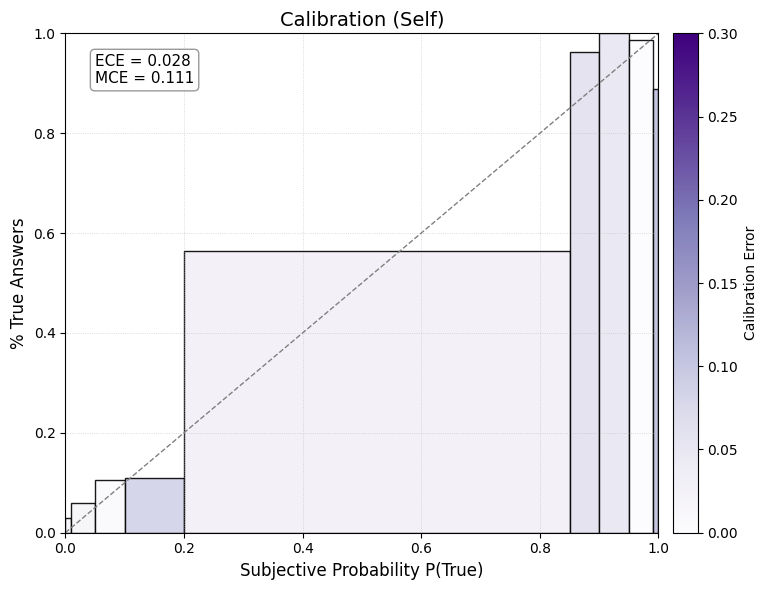

In [ ]:
bin_stats, bin_edges = calibration_curve(conf_self, y_pred, n_bins=10, quantile_binning=True)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the reliability diagram
plot_reliability_diagram(
    bin_stats=bin_stats,
    bin_edges=bin_edges,
    ax=ax,
    title="Calibration (Self)",
    cmap=cmapz['self']  # or any other colormap like 'coolwarm', 'Blues', etc.
)

plt.tight_layout()
plt.show()

# Analysis

### Legacy tests

In [ ]:
cossims = []

for direction in directions:

    cossims.append(cosine_similarity(direction.reshape(1, -1), mm.reshape(1, -1))[0])

print(np.array(cossims).mean())

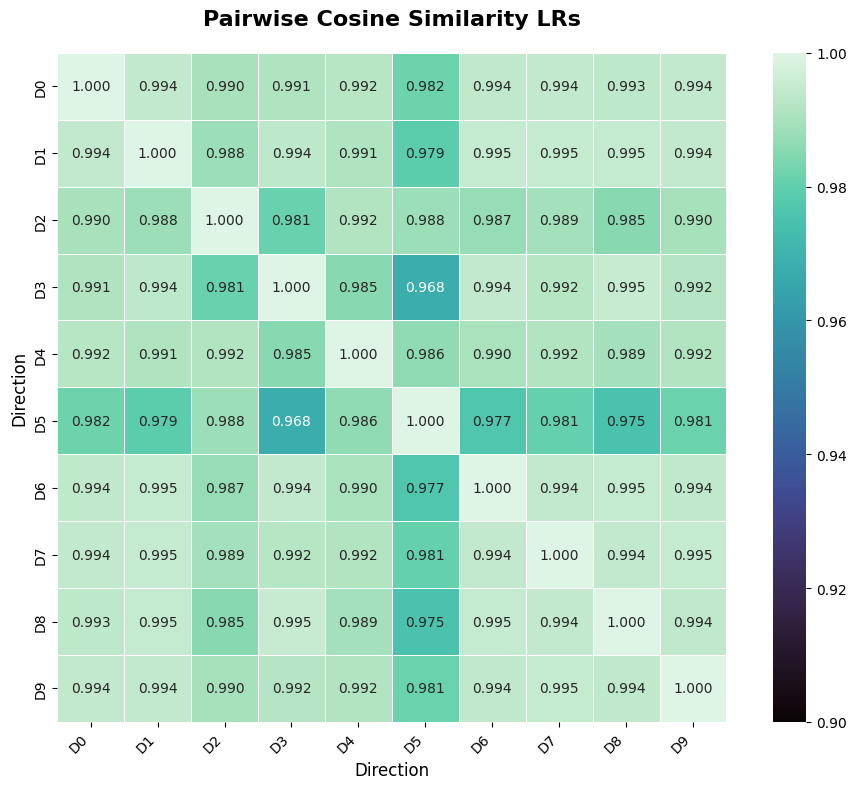

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def plot_cosine_similarity_heatmap(sim_matrix, labels=None):
    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        sim_matrix,
        xticklabels=labels,
        yticklabels=labels,
        cmap="mako",
        annot=True,
        fmt=".3f",
        vmin=0.9,
        vmax=1.000,
        linewidths=0.5,
        linecolor='white',
        square=True,
        cbar_kws={"shrink": 1.00}
    )

    ax.set_title("Pairwise Cosine Similarity LRs", fontsize=16, weight='bold', pad=20)
    ax.set_xlabel("Direction", fontsize=12)
    ax.set_ylabel("Direction", fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    plt.show()
def cosine_matrix(vectors):

    similarity_matrix = cosine_similarity(vectors)
    labels = [f'D{i}' for i in range(len(vectors))]
    plot_cosine_similarity_heatmap(similarity_matrix, labels)
    return similarity_matrix

similarity_matrix = cosine_matrix(directions)

In [ ]:
accuracies_simple = orthogonal_probing(probe_config, X_train, y_train, X_test, y_test, n=20, fix_direction=None)

Epochs:  28%|██▊       | 280/1000 [00:48<02:03,  5.83it/s]


Early stopping triggered at epoch 281
Run 1/20 accuracy: 0.8619


Epochs:  19%|█▉        | 189/1000 [00:33<02:21,  5.72it/s]

Early stopping triggered at epoch 190
Run 2/20 accuracy: 0.6212



Epochs:   8%|▊         | 81/1000 [00:14<02:39,  5.75it/s]


...

Early stopping triggered at epoch 38
Run 18/20 accuracy: 0.5162


Epochs:   3%|▎         | 32/1000 [00:05<02:48,  5.73it/s]


Early stopping triggered at epoch 33
Run 19/20 accuracy: 0.5152


Epochs:   2%|▏         | 23/1000 [00:04<02:58,  5.48it/s]

Early stopping triggered at epoch 24
Run 20/20 accuracy: 0.4920


In [ ]:
accuracies_mm = orthogonal_probing(probe_config, X_train, y_train, X_test, y_test, n=19, fix_direction=mm)

accuracies_mm.insert(0, mm_acc)

Epochs:   1%|▏         | 14/1000 [00:02<02:41,  6.11it/s]


Early stopping triggered at epoch 15
Run 1/19 accuracy: 0.4810


Epochs:   3%|▎         | 27/1000 [00:04<02:51,  5.67it/s]


Early stopping triggered at epoch 28
Run 2/19 accuracy: 0.4800


Epochs:   2%|▏         | 24/1000 [00:04<02:55,  5.55it/s]


...

Early stopping triggered at epoch 28
Run 17/19 accuracy: 0.4978


Epochs:   2%|▏         | 20/1000 [00:03<03:00,  5.43it/s]


Early stopping triggered at epoch 21
Run 18/19 accuracy: 0.5015


Epochs:   2%|▎         | 25/1000 [00:04<02:54,  5.59it/s]

Early stopping triggered at epoch 26
Run 19/19 accuracy: 0.4745


In [ ]:
master_probe_direction = next(param for param in master_probe.parameters()).cpu().numpy()
accuracies_master = orthogonal_probing(probe_config, X_train, y_train, X_test, y_test, n=19, fix_direction=master_probe_direction)
accuracies_master.insert(0, accuracy) # accuracy = accuracy for the master probe

Epochs:  11%|█▏        | 113/1000 [00:19<02:32,  5.81it/s]


Early stopping triggered at epoch 114
Run 1/19 accuracy: 0.6195


Epochs:   5%|▍         | 46/1000 [00:08<02:50,  5.60it/s]


Early stopping triggered at epoch 47
Run 2/19 accuracy: 0.6362


Epochs:   5%|▌         | 52/1000 [00:09<02:45,  5.71it/s]


...

Early stopping triggered at epoch 36
Run 17/19 accuracy: 0.4950


Epochs:   4%|▎         | 37/1000 [00:06<02:55,  5.50it/s]


Early stopping triggered at epoch 38
Run 18/19 accuracy: 0.5169


Epochs:   3%|▎         | 32/1000 [00:05<02:46,  5.80it/s]

Early stopping triggered at epoch 33
Run 19/19 accuracy: 0.5091


In [ ]:
accuracies_master[0] = accuracies_master[0].cpu().numpy()

In [ ]:
accuracies = {'Mass-mean': accuracies_mm, 'LR': accuracies_simple, 'Average LR': accuracies_master}

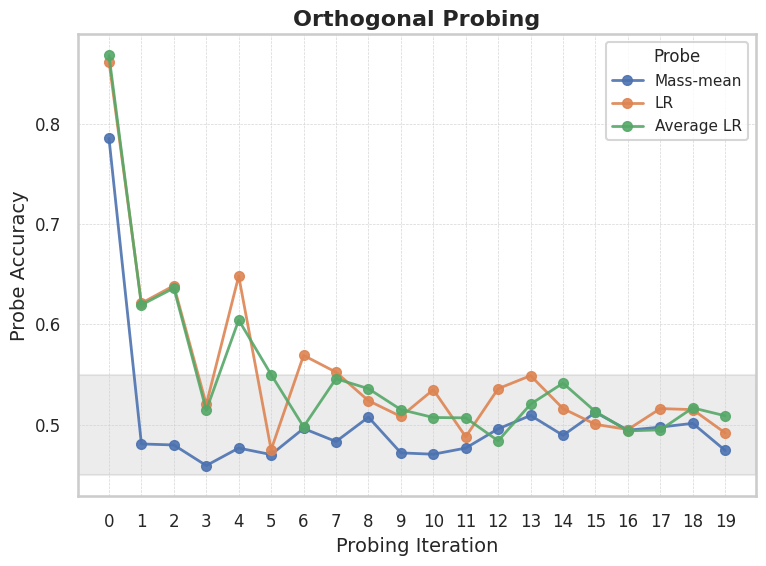

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set seaborn style for better aesthetics
sns.set(style="whitegrid", context="talk", palette="deep")

plt.figure(figsize=(8, 6))  # Wider figure for better spacing

for key, value in accuracies.items():
    plt.plot(value, label=key, linewidth=2, marker='o', markersize=7, alpha=0.9)

plt.xlabel('Probing Iteration', fontsize=14)
plt.ylabel('Probe Accuracy', fontsize=14)
plt.title('Orthogonal Probing', fontsize=16, weight='bold')
plt.axhspan(0.45, 0.55, color='grey', alpha=0.15, zorder=0)
plt.xticks(fontsize=12, ticks=range(20))
plt.yticks(fontsize=12)
plt.legend(title="Probe", fontsize=11, title_fontsize=12, loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.8)

plt.tight_layout()
plt.show()


In [ ]:
ex_prompt = 'If you eat a grape you die. This statement is:'
with t.no_grad():
  truth, conf = self_reporting_confidence(model, ex_prompt, context='Use the whole range from 0 to 1 to express precise confidence.')
  print(truth, conf)

# Adapt to whole dataframe

False. 0.9


In [ ]:

import torch as t

randt0 = t.rand(1950)
randt1 = t.rand(1950)

(proba1 - proba2).abs().mean().item()

NameError: name 'proba1' is not defined